# XGBoost Models

This notebook documents the XGBoost model family used as a nonlinear benchmark alongside Random Forest.

The notebook covers:

1. motivation for using XGBoost  
2. comparison of the `daily` and `daily_ohlcv` feature sources  
3. prediction and portfolio results  
4. feature importance analysis  
5. interpretation of train-test generalization  
6. explanation of why XGBoost was not selected as the final model  

The objective is to compare a stronger boosted-tree learner against the Random Forest family and assess whether higher in-sample fit translates into better out-of-sample performance.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
    plot_feature_importance,
)

In [3]:
NOTEBOOK_NAME = "notebook06"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook06


In [4]:
def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> pd.DataFrame:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")
    return df


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Why use XGBoost?

XGBoost is included because it is a powerful boosted-tree model for structured tabular data.

It is relevant in this project because:

- it can fit nonlinear relationships
- it can model complex feature interactions
- it often performs strongly on structured prediction problems

However, stronger in-sample fit does not automatically imply better out-of-sample stock ranking or better portfolio construction. This notebook evaluates that question directly.

In [5]:
xgb_dirs = {
    "XGBoost daily": PROJECT_ROOT / "experiments" / "results" / "exp03_xgboost_rolling_daily",
    "XGBoost daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp03_xgboost_rolling_daily_ohlcv",
}

xgb_dirs

{'XGBoost daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp03_xgboost_rolling_daily'),
 'XGBoost daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp03_xgboost_rolling_daily_ohlcv')}

In [6]:
for name, xgb_dir in xgb_dirs.items():
    print(f"\n{name}")
    print("dir:", xgb_dir)
    for fn in [
        "prediction_metrics.json",
        "metrics_train.json",
        "metrics_test_2025.json",
        "metrics_train_with_costs.json",
        "metrics_test_2025_with_costs.json",
        "equity_train.csv",
        "equity_test_2025.csv",
        "feature_importance_mean.csv",
        "test_predictions.csv",
    ]:
        print(f"{fn}: {(xgb_dir / fn).exists()}")


XGBoost daily
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp03_xgboost_rolling_daily
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True
feature_importance_mean.csv: True
test_predictions.csv: True

XGBoost daily_ohlcv
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp03_xgboost_rolling_daily_ohlcv
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True
feature_importance_mean.csv: True
test_predictions.csv: True


In [7]:
def load_xgb_experiment(exp_dir: Path) -> dict:
    with open(exp_dir / "prediction_metrics.json", "r") as f:
        prediction_metrics = json.load(f)

    with open(exp_dir / "metrics_train.json", "r") as f:
        metrics_train = json.load(f)

    with open(exp_dir / "metrics_test_2025.json", "r") as f:
        metrics_test = json.load(f)

    with open(exp_dir / "metrics_train_with_costs.json", "r") as f:
        metrics_train_costs = json.load(f)

    with open(exp_dir / "metrics_test_2025_with_costs.json", "r") as f:
        metrics_test_costs = json.load(f)

    equity_train = pd.read_csv(exp_dir / "equity_train.csv", index_col=0).squeeze("columns")
    equity_test = pd.read_csv(exp_dir / "equity_test_2025.csv", index_col=0).squeeze("columns")

    equity_train.index = pd.to_datetime(equity_train.index)
    equity_test.index = pd.to_datetime(equity_test.index)

    feat_imp = pd.read_csv(exp_dir / "feature_importance_mean.csv", index_col=0) if (exp_dir / "feature_importance_mean.csv").exists() else None
    test_pred = pd.read_csv(exp_dir / "test_predictions.csv") if (exp_dir / "test_predictions.csv").exists() else None

    return {
        "prediction_metrics": prediction_metrics,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "metrics_train_costs": metrics_train_costs,
        "metrics_test_costs": metrics_test_costs,
        "equity_train": equity_train,
        "equity_test": equity_test,
        "feature_importance": feat_imp,
        "test_predictions": test_pred,
    }

In [8]:
xgb_results = {name: load_xgb_experiment(path) for name, path in xgb_dirs.items()}
xgb_results.keys()

dict_keys(['XGBoost daily', 'XGBoost daily_ohlcv'])

In [9]:
xgb_setup = save_table(
    pd.DataFrame(
        {
            "model_variant": ["XGBoost daily", "XGBoost daily_ohlcv"],
            "feature_source": ["daily", "daily_ohlcv"],
            "training_scheme": ["rolling", "rolling"],
            "model_family": ["XGBoost", "XGBoost"],
        }
    ),
    "xgb_setup_summary.csv",
    index=False,
)
xgb_setup

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06\xgb_setup_summary.csv


,model_variant,feature_source,training_scheme,model_family
0,XGBoost daily,daily,rolling,XGBoost
1,XGBoost daily_ohlcv,daily_ohlcv,rolling,XGBoost


## 2. Prediction metrics

The XGBoost models are first evaluated as return prediction models.

These metrics describe:

- numerical return prediction quality  
- sign correctness  
- ranking quality across stocks within each month

In [10]:
prediction_rows = []

for model_name, res in xgb_results.items():
    pm = res["prediction_metrics"]

    prediction_rows.append(
        {
            "model": model_name,
            "split": "train_static_fit",
            "MAE": pm["train_static_fit"]["regression"]["MAE"],
            "RMSE": pm["train_static_fit"]["regression"]["RMSE"],
            "R2": pm["train_static_fit"]["regression"]["R2"],
            "Directional_Accuracy": pm["train_static_fit"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["train_static_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["train_static_fit"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["train_static_fit"]["ranking"]["Months_evaluated"],
        }
    )

    prediction_rows.append(
        {
            "model": model_name,
            "split": "test_2025_rolling_fit",
            "MAE": pm["test_2025_rolling_fit"]["regression"]["MAE"],
            "RMSE": pm["test_2025_rolling_fit"]["regression"]["RMSE"],
            "R2": pm["test_2025_rolling_fit"]["regression"]["R2"],
            "Directional_Accuracy": pm["test_2025_rolling_fit"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["test_2025_rolling_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["test_2025_rolling_fit"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["test_2025_rolling_fit"]["ranking"]["Months_evaluated"],
        }
    )

xgb_prediction_comparison = save_table(
    pd.DataFrame(prediction_rows),
    "xgb_prediction_metrics_comparison.csv",
    index=False,
)
xgb_prediction_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06\xgb_prediction_metrics_comparison.csv


,model,split,MAE,RMSE,R2,Directional_Accuracy,SpearmanRankCorr_mean,TopKHitRate_mean,Months_evaluated
0,XGBoost daily,train_static_fit,0.054110,0.071271,0.239008,0.605011,0.278567,0.378102,109
1,XGBoost daily,test_2025_rolling_fit,0.055150,0.073978,0.001008,0.536133,0.055333,0.320574,11
2,XGBoost daily_ohlcv,train_static_fit,0.053191,0.069820,0.267435,0.621361,0.317149,0.387226,109
3,XGBoost daily_ohlcv,test_2025_rolling_fit,0.055223,0.074440,-0.011523,0.554688,0.037959,0.296651,11


In [11]:
strategy_rows = []

for model_name, res in xgb_results.items():
    strategy_rows.append({"model": model_name, "split": "train_2015_2024", **res["metrics_train"]})
    strategy_rows.append({"model": model_name, "split": "test_2025", **res["metrics_test"]})

xgb_strategy_comparison = save_table(
    pd.DataFrame(strategy_rows),
    "xgb_strategy_metrics_comparison.csv",
    index=False,
)
xgb_strategy_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06\xgb_strategy_metrics_comparison.csv


,model,split,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,XGBoost daily,train_2015_2024,62.917551,0.515521,0.200281,-0.191708,2.203283,0.647248,0.650000,1.000000
1,XGBoost daily,test_2025,0.306814,0.306814,0.133432,-0.045293,2.087148,0.488038,0.526316,0.684211
2,XGBoost daily_ohlcv,train_2015_2024,94.073021,0.576906,0.195676,-0.169722,2.460817,0.627982,0.650000,1.000000
3,XGBoost daily_ohlcv,test_2025,0.278509,0.278509,0.122549,-0.050368,2.080711,0.483254,0.526316,0.684211


In [12]:
cost_rows = []

for model_name, res in xgb_results.items():
    for split_name, cost_dict in [
        ("train_2015_2024", res["metrics_train_costs"]),
        ("test_2025", res["metrics_test_costs"]),
    ]:
        for cost_name, metrics in cost_dict.items():
            row = {"model": model_name, "split": split_name, "cost_scenario": cost_name}
            row.update(metrics)
            cost_rows.append(row)

xgb_cost_comparison = save_table(
    pd.DataFrame(cost_rows),
    "xgb_cost_adjusted_comparison.csv",
    index=False,
)
xgb_cost_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06\xgb_cost_adjusted_comparison.csv


,model,split,cost_scenario,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,XGBoost daily,train_2015_2024,cost_0bps,62.917551,0.515521,0.200281,-0.191708,2.203283,0.647248,0.650000,1.000000
1,XGBoost daily,train_2015_2024,cost_10bps,58.712374,0.505242,0.200163,-0.193538,2.169340,0.647248,0.650000,1.000000
2,XGBoost daily,train_2015_2024,cost_20bps,54.781359,0.495027,0.200048,-0.195365,2.135322,0.647248,0.650000,1.000000
3,XGBoost daily,test_2025,cost_0bps,0.306814,0.306814,0.133432,-0.045293,2.087148,0.488038,0.526316,0.684211
4,XGBoost daily,test_2025,cost_10bps,0.299978,0.299978,0.133341,-0.045977,2.048309,0.488038,0.526316,0.684211
5,XGBoost daily,test_2025,cost_20bps,0.293174,0.293174,0.133255,-0.046661,2.009352,0.488038,0.526316,0.684211
6,XGBoost daily_ohlcv,train_2015_2024,cost_0bps,94.073021,0.576906,0.195676,-0.169722,2.460817,0.627982,0.650000,1.000000
7,XGBoost daily_ohlcv,train_2015_2024,cost_10bps,88.014794,0.566557,0.195582,-0.171709,2.427002,0.627982,0.650000,1.000000
8,XGBoost daily_ohlcv,train_2015_2024,cost_20bps,82.339103,0.556270,0.195491,-0.173692,2.393117,0.627982,0.650000,1.000000
9,XGBoost daily_ohlcv,test_2025,cost_0bps,0.278509,0.278509,0.122549,-0.050368,2.080711,0.483254,0.526316,0.684211


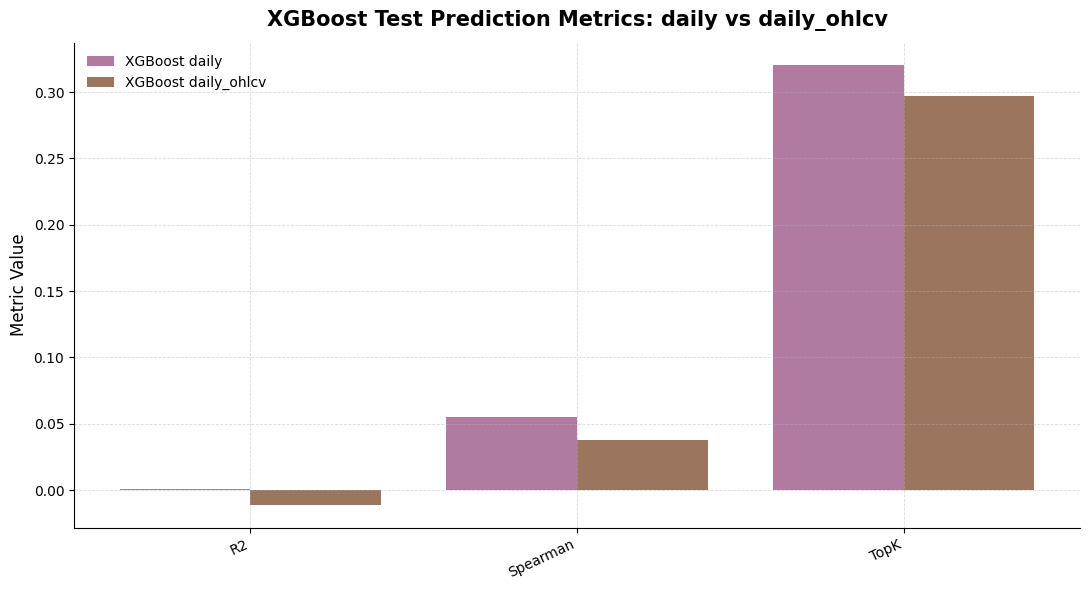

In [13]:
xgb_test_pred = xgb_prediction_comparison[
    xgb_prediction_comparison["split"] == "test_2025_rolling_fit"
].set_index("model")

xgb_metric_plot_df = pd.DataFrame(
    {
        "R2": xgb_test_pred["R2"],
        "Spearman": xgb_test_pred["SpearmanRankCorr_mean"],
        "TopK": xgb_test_pred["TopKHitRate_mean"],
    }
).T

plot_grouped_metric_bars(
    metric_df=xgb_metric_plot_df,
    title="XGBoost Test Prediction Metrics: daily vs daily_ohlcv",
    ylabel="Metric Value",
    color_map={
        "XGBoost daily": get_model_color("xgboost"),
        "XGBoost daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("xgb_test_prediction_metric_comparison.png"),
    show=True,
)

## 3. Equity curves

The cumulative-value paths of the XGBoost portfolios are compared below for both the training and test periods.

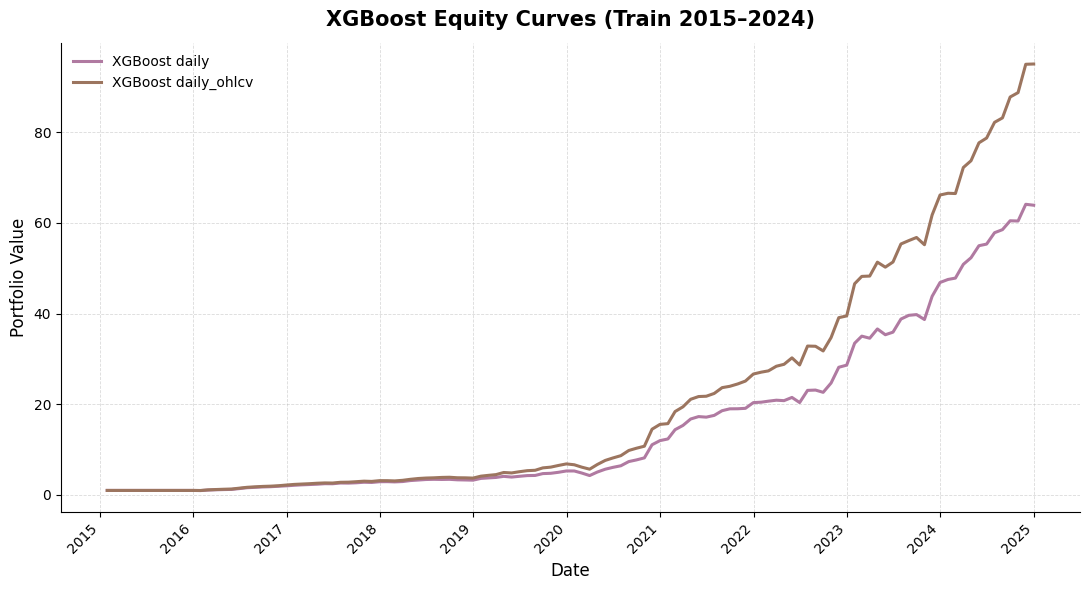

In [14]:
plot_multi_series(
    series_map={
        "XGBoost daily": xgb_results["XGBoost daily"]["equity_train"],
        "XGBoost daily_ohlcv": xgb_results["XGBoost daily_ohlcv"]["equity_train"],
    },
    title="XGBoost Equity Curves (Train 2015–2024)",
    ylabel="Portfolio Value",
    color_map={
        "XGBoost daily": get_model_color("xgboost"),
        "XGBoost daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("xgb_equity_train_comparison.png"),
    show=True,
)

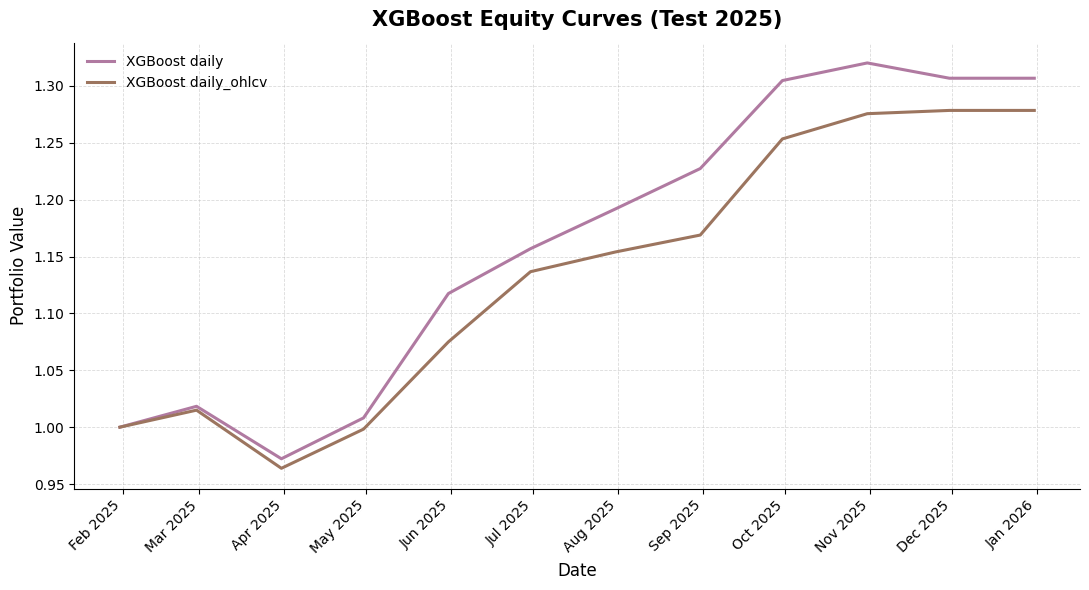

In [15]:
plot_multi_series(
    series_map={
        "XGBoost daily": xgb_results["XGBoost daily"]["equity_test"],
        "XGBoost daily_ohlcv": xgb_results["XGBoost daily_ohlcv"]["equity_test"],
    },
    title="XGBoost Equity Curves (Test 2025)",
    ylabel="Portfolio Value",
    color_map={
        "XGBoost daily": get_model_color("xgboost"),
        "XGBoost daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("xgb_equity_test_comparison.png"),
    show=True,
)

## 4. Drawdowns

Drawdown plots complement the equity curves by showing the magnitude of losses from prior peaks.

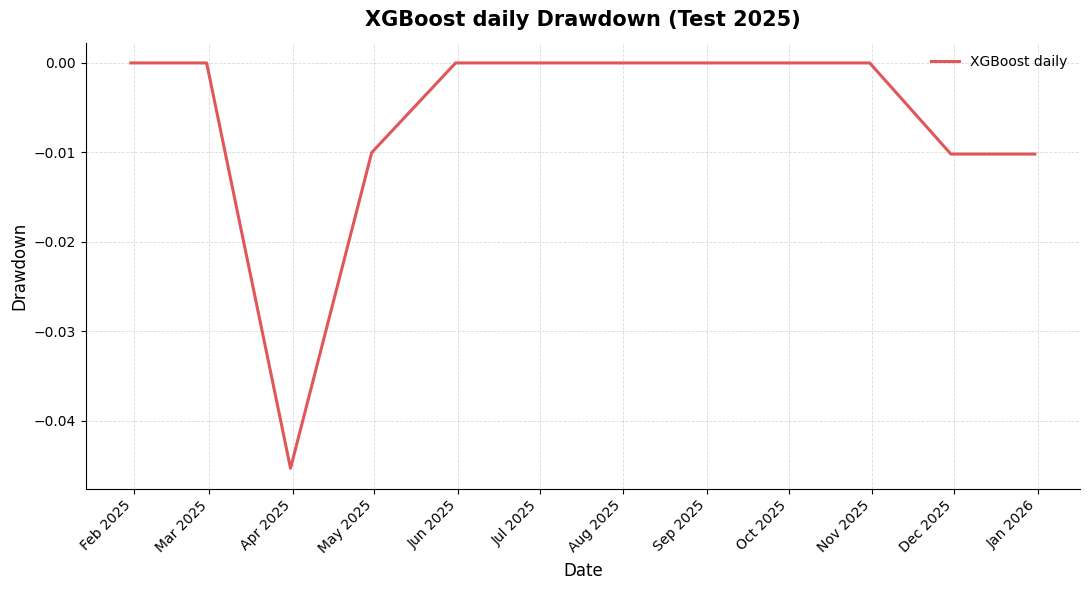

In [16]:
plot_drawdown(
    xgb_results["XGBoost daily"]["equity_test"],
    title="XGBoost daily Drawdown (Test 2025)",
    save_path=fig_path("xgb_daily_drawdown_test.png"),
    label="XGBoost daily",
    color="#E15759",
    show=True,
)

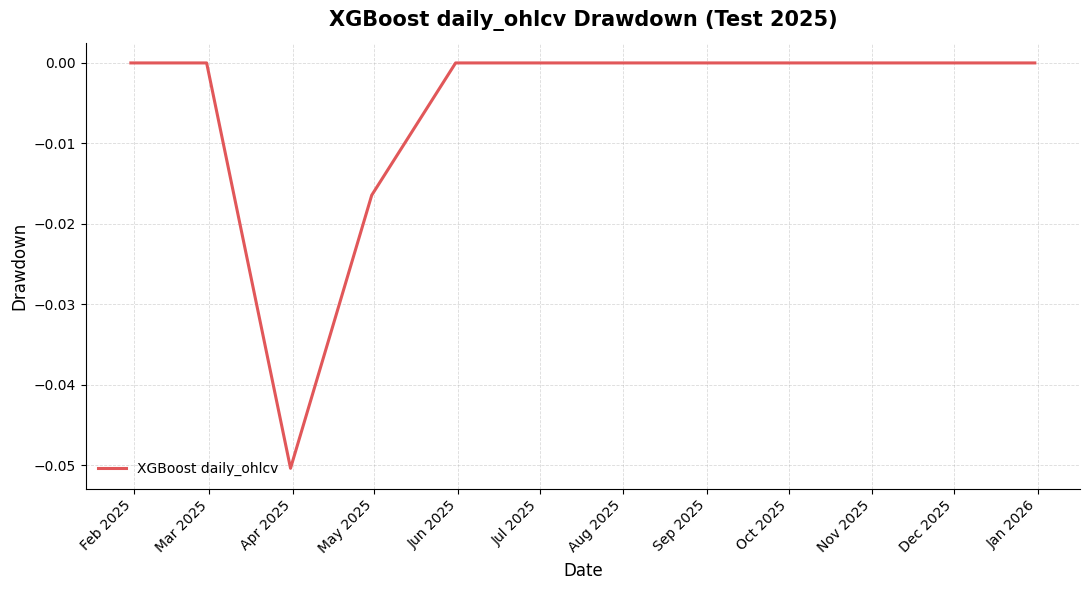

In [17]:
plot_drawdown(
    xgb_results["XGBoost daily_ohlcv"]["equity_test"],
    title="XGBoost daily_ohlcv Drawdown (Test 2025)",
    save_path=fig_path("xgb_daily_ohlcv_drawdown_test.png"),
    label="XGBoost daily_ohlcv",
    color="#E15759",
    show=True,
)

In [18]:
xgb_test_strategy = xgb_strategy_comparison[xgb_strategy_comparison["split"] == "test_2025"].set_index("model")
xgb_test_strategy[["cumulative_return", "annualized_return", "sharpe_ratio", "avg_turnover"]]

,cumulative_return,annualized_return,sharpe_ratio,avg_turnover
model,,,,
XGBoost daily,0.306814,0.306814,2.087148,0.488038
XGBoost daily_ohlcv,0.278509,0.278509,2.080711,0.483254


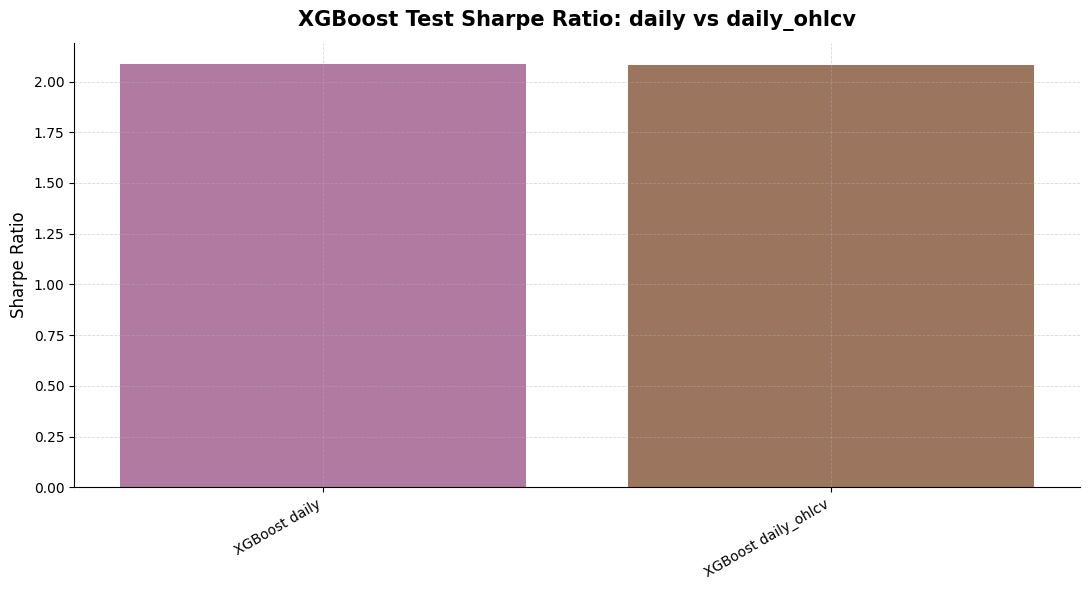

In [19]:
plot_metric_bar(
    xgb_test_strategy["sharpe_ratio"],
    title="XGBoost Test Sharpe Ratio: daily vs daily_ohlcv",
    ylabel="Sharpe Ratio",
    color_map={
        "XGBoost daily": get_model_color("xgboost"),
        "XGBoost daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("xgb_test_sharpe_comparison.png"),
    show=True,
)

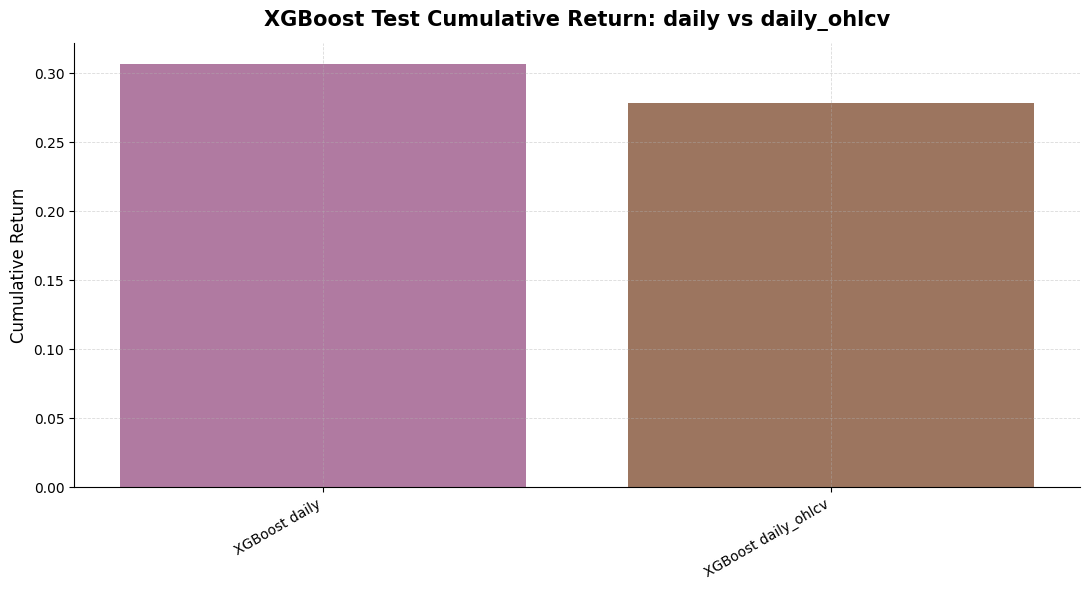

In [20]:
plot_metric_bar(
    xgb_test_strategy["cumulative_return"],
    title="XGBoost Test Cumulative Return: daily vs daily_ohlcv",
    ylabel="Cumulative Return",
    color_map={
        "XGBoost daily": get_model_color("xgboost"),
        "XGBoost daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("xgb_test_cumulative_return_comparison.png"),
    show=True,
)

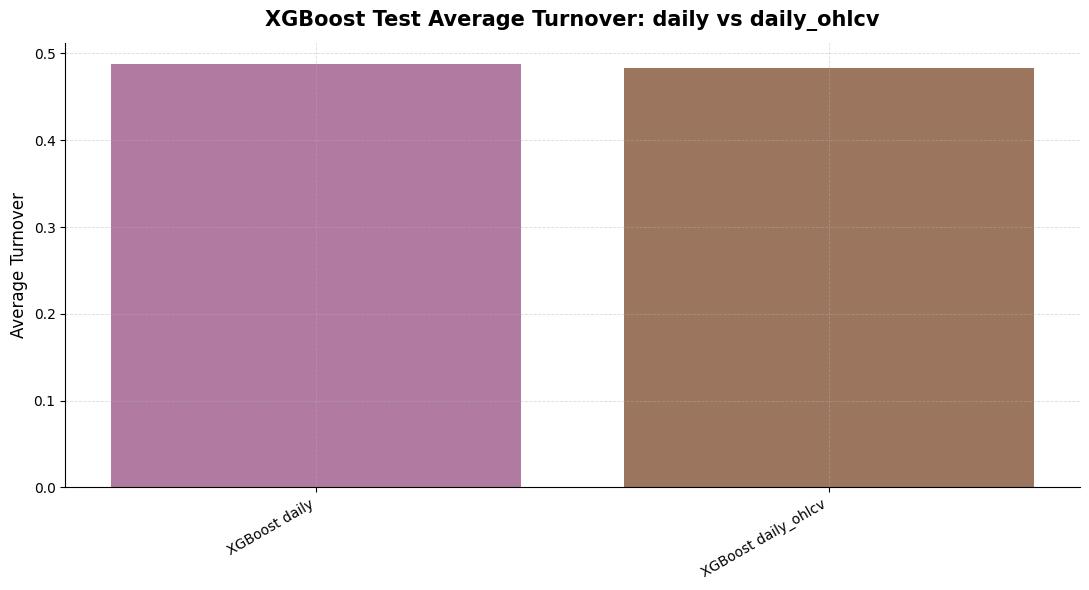

In [21]:
plot_metric_bar(
    xgb_test_strategy["avg_turnover"],
    title="XGBoost Test Average Turnover: daily vs daily_ohlcv",
    ylabel="Average Turnover",
    color_map={
        "XGBoost daily": get_model_color("xgboost"),
        "XGBoost daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("xgb_test_turnover_comparison.png"),
    show=True,
)

## 5. Feature importance

Feature importance provides a useful interpretation aid for the XGBoost models, where available.

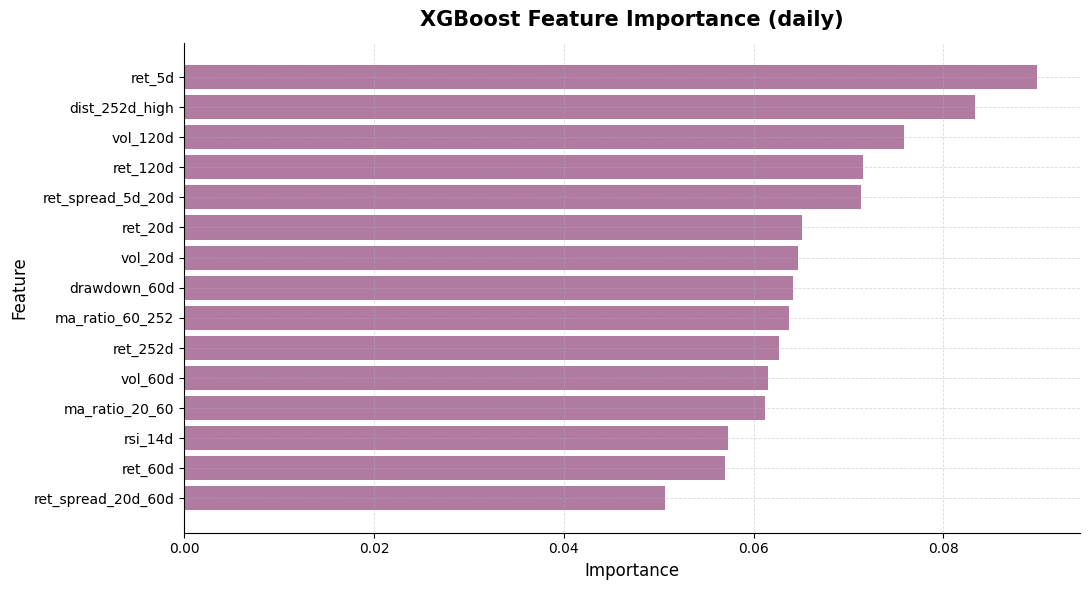

In [22]:
feat_imp_daily = xgb_results["XGBoost daily"]["feature_importance"]

if feat_imp_daily is not None:
    imp_series = feat_imp_daily["importance_mean"]
    plot_feature_importance(
        imp_series,
        title="XGBoost Feature Importance (daily)",
        top_n=20,
        save_path=fig_path("xgb_daily_feature_importance.png"),
        color=get_model_color("xgboost"),
        show=True,
    )
else:
    print("No feature importance file found for XGBoost daily.")

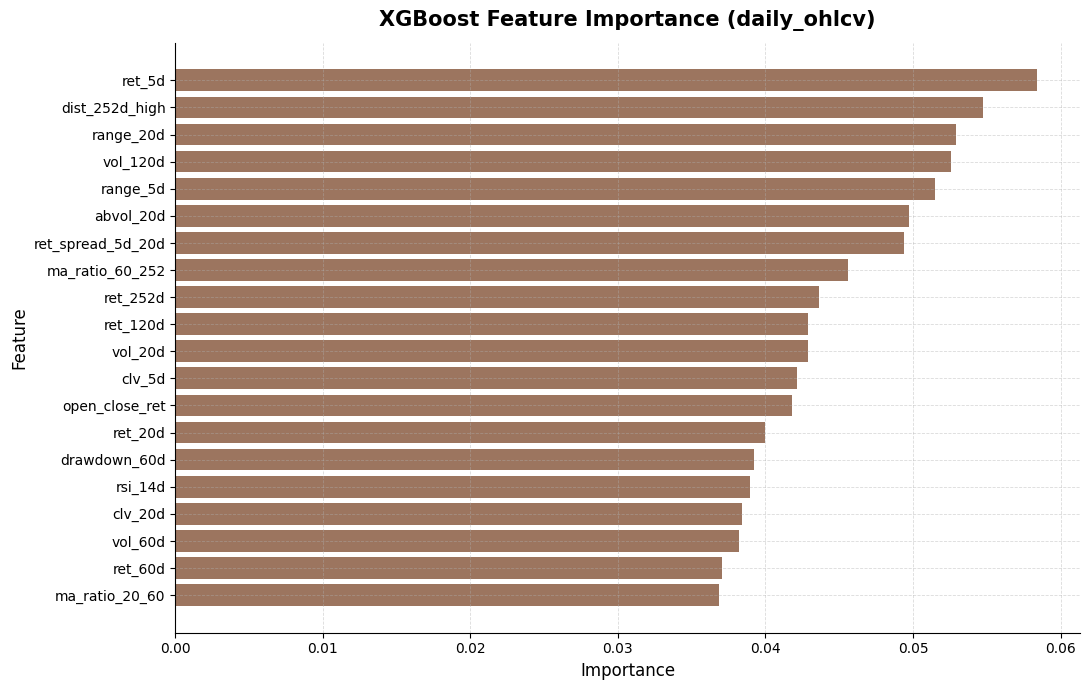

In [23]:
feat_imp_ohlcv = xgb_results["XGBoost daily_ohlcv"]["feature_importance"]

if feat_imp_ohlcv is not None:
    imp_series = feat_imp_ohlcv["importance_mean"]
    plot_feature_importance(
        imp_series,
        title="XGBoost Feature Importance (daily_ohlcv)",
        top_n=20,
        save_path=fig_path("xgb_daily_ohlcv_feature_importance.png"),
        color="#9C755F",
        show=True,
    )
else:
    print("No feature importance file found for XGBoost daily_ohlcv.")

## 6. Generalization pattern

A central pattern in the XGBoost results is the gap between training performance and test performance.

The model often achieved:

- stronger in-sample fit  
- stronger train ranking metrics  
- but weaker out-of-sample generalization than the best Random Forest variant  

This pattern suggests that the boosted-tree model captured more structure in-sample, but that this additional flexibility did not translate into superior 2025 portfolio performance.

In [24]:
xgb_gap_rows = []

for model_name, res in xgb_results.items():
    pm = res["prediction_metrics"]
    xgb_gap_rows.append(
        {
            "model": model_name,
            "train_R2": pm["train_static_fit"]["regression"]["R2"],
            "test_R2": pm["test_2025_rolling_fit"]["regression"]["R2"],
            "train_Spearman": pm["train_static_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "test_Spearman": pm["test_2025_rolling_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "train_TopK": pm["train_static_fit"]["ranking"]["TopKHitRate_mean"],
            "test_TopK": pm["test_2025_rolling_fit"]["ranking"]["TopKHitRate_mean"],
        }
    )

xgb_gap_table = save_table(
    pd.DataFrame(xgb_gap_rows),
    "xgb_train_test_gap_summary.csv",
    index=False,
)
xgb_gap_table

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06\xgb_train_test_gap_summary.csv


,model,train_R2,test_R2,train_Spearman,test_Spearman,train_TopK,test_TopK
0,XGBoost daily,0.239008,0.001008,0.278567,0.055333,0.378102,0.320574
1,XGBoost daily_ohlcv,0.267435,-0.011523,0.317149,0.037959,0.387226,0.296651


## 7. Interpretation

The XGBoost family produced several important findings:

- XGBoost achieved stronger in-sample fit than Ridge and often stronger in-sample fit than Random Forest  
- the OHLCV extension did not produce the same level of out-of-sample benefit here as it did for Random Forest  
- higher flexibility led to stronger training performance, but not to stronger final 2025 ranking and portfolio performance  
- out-of-sample generalization remained weaker than the selected Random Forest model  

These findings explain why XGBoost was retained as a strong nonlinear comparison model, but not selected as the final model.

In [25]:
xgb_findings = save_table(
    pd.DataFrame(
        {
            "finding": [
                "XGBoost provided a strong nonlinear comparison model",
                "In-sample fit was stronger than the final selected Random Forest in several cases",
                "Out-of-sample generalization remained weaker than the best Random Forest variant",
                "The train-test gap provided evidence of overfitting pressure",
                "XGBoost was not selected as the final model",
            ]
        }
    ),
    "xgb_key_findings.csv",
    index=False,
)
xgb_findings

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook06\xgb_key_findings.csv


,finding
0,XGBoost provided a strong nonlinear comparison...
1,In-sample fit was stronger than the final sele...
2,Out-of-sample generalization remained weaker t...
3,The train-test gap provided evidence of overfi...
4,XGBoost was not selected as the final model


## 8. Final conclusion

The XGBoost model family served as an important nonlinear benchmark in the project.

It provided:

- stronger in-sample fit  
- informative feature-importance patterns  
- a useful contrast with the Random Forest family  

However, the best Random Forest model achieved stronger out-of-sample ranking quality, better portfolio performance, and better turnover behavior. For that reason, XGBoost was not selected as the final model.